# **Atividade Prática**
<font size=3>

- **Tema:** Problema de busca.
- **Prazo de entrega:** 15 de Setembro.

---

## **Enunciado:**
<font size=3>
    
Baseado no **_notebook_ 3.2** ("Exemplo de Busca em Largura"), desenvolva duas soluções para encontrar uma rota em um mapa: uma com um algoritmo de **busca desinformada** e outra com um de **busca informada**.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive/')

---

### **1. Questão — Busca Desinformada:**
#### **1.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca desinformada** (que não seja *Busca em Largura*);

- Defina as coordenadas de origem e destino (*no Google Maps, ao clinar em uma posição no mapa com o botão direito, as coordenadas aparecem em um aba*);

- Defina o modo de percurso ("*drive*", "*walk*", "*bike*" ou "*all*");

- Execute a busca, **imprima na tela** as ruas do caminho encontrado e faça o **plote do mapa**.


In [ ]:
%pip install osmnx
%pip install matplotlib
%pip install scikit-learn

In [43]:
import osmnx as ox
import numpy as np
import heapq
import matplotlib.pyplot as plt
from collections import deque

In [14]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl   = np.deg2rad(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2.0)**2

    return 2*R*np.arcsin(np.sqrt(a))


def graph(lat_o, lon_o, lat_d, lon_d, mode = "walk", margin = 500):

    """
    Baixa um grafo OSM que cobre a área entre origem e destino, com margem extra.
    mode: 'drive' | 'walk' | 'bike' | 'all'
    """

    dist = haversine(lat_o, lon_o, lat_d, lon_d) + margin

    lat_c = (lat_o + lat_d)/2
    lon_c = (lon_o + lon_d)/2

    return ox.graph_from_point(center_point = (lat_c, lon_c), dist = dist, network_type = mode, simplify = True)


def edges2streets(G, path_nodes):

    streets = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        data_options = G.get_edge_data(u, v)

        if not data_options: # mão oposta, se necessário
            data_options = G.get_edge_data(v, u)
        if not data_options:
            streets.append("(desconhecida)")
            continue

        data = list(data_options.values())[0]
        name = data.get('name')

        if isinstance(name, list) and name:
            streets.append(name[0])
        elif isinstance(name, str) and name.strip():
            streets.append(name)
        else:
            streets.append("(sem nome)")

    return streets

In [16]:
class Problem:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    # função actions(state) -> iterável de actions
        self.transition_model = transition_model  # função (state, action) -> new_state
        self.goal_test = goal_test                # função (state) -> bool
        self.step_cost = step_cost                # função (state, action) -> custo

class Node:

    def __init__(self, problem, parent = None, action = None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = problem.initial_state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        return isinstance(other, Node) and self.state == other.state


    def __hash__(self):

        return hash(self.state)


In [ ]:
class Node4Heap(Node):

    def __init__(self, problem, parent = None, action = None):
        super().__init__(problem, parent, action)

    def __lt__(self, other):

        return self.path_cost < other.path_cost

In [73]:
class UniformCostSearch:

    def __init__(self, problem):

        self.problem = problem
        self.frontier = []
        self.explored = set()

    def search(self):
        root = Node4Heap(problem = self.problem)

        heapq.heappush(self.frontier, (root.path_cost, root))

        while self.frontier:

            #Lembrar de encontrar uma maneira de usar o path_cost! Corrigir busca!
            path_cost, node = heapq.heappop(self.frontier)

            if node in self.explored:
                continue

            if self.problem.goal_test(node.state):
                return node

            self.explored.add(node)

            for action in self.problem.actions(node.state):
                child = Node4Heap(self.problem, node, action)

                if child not in self.explored:
                    heapq.heappush(self.frontier, (child.path_cost, child))

        return None


In [22]:
class MapProblem(Problem):

    """
    Estados = IDs de nós do grafo OSMNX (NetworkX).
    Ações(state) = nós vizinhos alcançáveis por uma aresta (sucessores).
    Modelo de transição(state, action) = action (vizinho escolhido).
    Custo de passo = 1 (BFS -> menor nº de arestas).
    """

    def __init__(self, G, start_node, goal_node):

        self.G = G
        self.goal_node = goal_node

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)


    def actions_fn(self, state):

        return self.G.successors(state) if hasattr(self.G, "successors") else self.G.neighbors(state)


    def transition_fn(self, state, action):
        return action


    def goal_test_fn(self, state):
        return state == self.goal_node


    def step_cost_fn(self, state, action, uniform_cost=True):

        if uniform_cost:
            return 1.0

        else:
            edge = self.G.get_edge_data(state, action)
            return edge[0]['length']

In [35]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.7842539491146345, -35.313161414434596
lat_goal, lon_goal = -5.832045868188761, -35.20547959029296
mode = "bike"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600)

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 4783745048
Goal node ID: 2800204106


In [78]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

# definindo o modelo de busca:
ucs = UniformCostSearch(problem)

# inicializando a busca:
goal_node = ucs.search()

In [38]:
# extraindo o caminho de nós da solução da busca:
node = goal_node
path = []

while node is not None:
    path.append(node.state)
    node = node.parent

path_nodes = list(reversed(path))

print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")

# Nós no caminho (UCS): 166  |  # arestas: 165


In [39]:
# imprimindo o nome das ruas da rota:
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")


Ruas percorridas (aproximadamente):

01. Rua Renato Leitão de Almeida
02. Rua Ceará
03. Rua Ceará
04. Rua 7
05. Rua 22
06. Rua 22
07. Rua 22
08. Rua 22
09. Rua Engenheiro Roberto Bezerra Freire
10. Rua Engenheiro Roberto Bezerra Freire
11. (sem nome)
12. (sem nome)
13. (sem nome)
14. (sem nome)
15. (sem nome)
16. (sem nome)
17. (sem nome)
18. (sem nome)
19. (sem nome)
20. Avenida Firmino Moura
21. Rua Pedro Miranda da Silva
22. Rua Pedro Miranda da Silva
23. Rua Pedro Miranda da Silva
24. Rua Pedro Miranda da Silva
25. Rua Pedro Miranda da Silva
26. (sem nome)
27. (sem nome)
28. Rua Alexandre Cavalcante
29. Rua Pedro de Alcantara Cavalcanti
30. Rua Pedro de Alcantara Cavalcanti
31. Rua Vereador Eri Teixeira Dantas
32. Rua Manoel Ferreira Gomes
33. Rua Manoel Ferreira Gomes
34. Rua Gonçalo Pinheiro
35. Rua Gonçalo Pinheiro
36. Rua Geraldo Cassemiro
37. Rua Geraldo Cassemiro
38. Rua Geraldo Cassemiro
39. Rua Geraldo Cassemiro
40. Rua José Horácio de Góis
41. Rua José Horácio de Góis
42. 

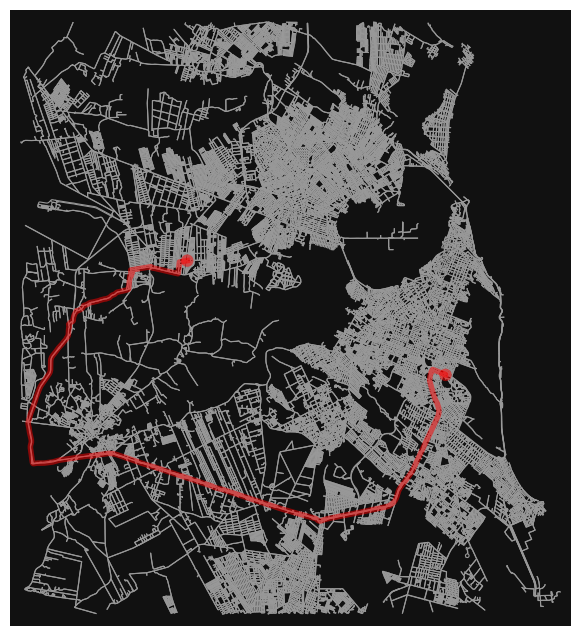

In [40]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()

#### **1.2 Análise:**
<font size=3>
    
Em uma **célula de markdown** compare o algoritmo que você escolheu com a **Busca em Largura (BFS)**, analisando os seguintes critérios:

- **Estrutura da Fronteira:** Qual estrutura de dados a fronteira utiliza (ex: Fila FIFO, Pilha LIFO, Fila de Prioridades)?

- **Otimalidade:** O seu algoritmo **garante** que a rota encontrada é a mais curta (com o menor número de ruas)? Justifique.

- **Complexidade:** Em geral, qual dos dois algoritmos (o seu ou o BFS) você espera que use mais memória para este problema de mapa? Por quê?
  

---

### **2. Questão — Busca Informada:**
#### **2.1 Implementação:**
<font size=3>

- Escolha um algoritmo de **busca informada**;

- Defina as coordenadas de origem e destino (diferença das usadas na **questão 1**);

- Defina o modo de percurso (diferença do usado na **questão 1**);

- Execute a busca, **imprima na tela** as ruas do caminho encontrado e faça o **plote do mapa**.


In [70]:
def haversine(lat1, lon1, lat2, lon2):

    R = 6371000.0
    p1 = np.deg2rad(lat1)
    p2 = np.deg2rad(lat2)
    dphi = np.deg2rad(lat2 - lat1)
    dl   = np.deg2rad(lon2 - lon1)

    a = np.sin(dphi/2.0)**2 + np.cos(p1)*np.cos(p2)*np.sin(dl/2.0)**2

    return 2*R*np.arcsin(np.sqrt(a))


def graph(lat_o, lon_o, lat_d, lon_d, mode = "walk", margin = 500):

    """
    Baixa um grafo OSM que cobre a área entre origem e destino, com margem extra.
    mode: 'drive' | 'walk' | 'bike' | 'all'
    """

    dist = haversine(lat_o, lon_o, lat_d, lon_d) + margin

    lat_c = (lat_o + lat_d)/2
    lon_c = (lon_o + lon_d)/2

    return ox.graph_from_point(center_point = (lat_c, lon_c), dist = dist, network_type = mode, simplify = True)


def edges2streets(G, path_nodes):

    streets = []
    for u, v in zip(path_nodes[:-1], path_nodes[1:]):
        data_options = G.get_edge_data(u, v)

        if not data_options: # mão oposta, se necessário
            data_options = G.get_edge_data(v, u)
        if not data_options:
            streets.append("(desconhecida)")
            continue

        data = list(data_options.values())[0]
        name = data.get('name')

        if isinstance(name, list) and name:
            streets.append(name[0])
        elif isinstance(name, str) and name.strip():
            streets.append(name)
        else:
            streets.append("(sem nome)")

    return streets

In [71]:
class Problem:

    def __init__(self, initial_state, actions, transition_model, goal_test, step_cost):

        self.initial_state = initial_state
        self.actions = actions                    # função actions(state) -> iterável de actions
        self.transition_model = transition_model  # função (state, action) -> new_state
        self.goal_test = goal_test                # função (state) -> bool
        self.step_cost = step_cost                # função (state, action) -> custo

class Node:

    def __init__(self, problem, parent = None, action = None):

        self.parent = parent
        self.action = action

        if parent is None:
            self.state = problem.initial_state
            self.path_cost = 0.0
        else:
            self.state = problem.transition_model(parent.state, action)
            self.path_cost = parent.path_cost + problem.step_cost(parent.state, action)


    def __eq__(self, other):

        return isinstance(other, Node) and self.state == other.state


    def __hash__(self):

        return hash(self.state)

In [72]:
class Node4Heap(Node):

    def __init__(self, problem, parent = None, action = None):
        super().__init__(problem, parent, action)

    def __lt__(self, other):

        return self.path_cost < other.path_cost

In [64]:
class Heuristic:

    def __init__(self, graph, goal_state):

        self.G = graph
        self.goal = goal_state

    def __call__(self, state):

        node_coords = (self.G.nodes[state]['y'], self.G.nodes[state]['x'])
        goal_coords = (self.G.nodes[self.goal]['y'], self.G.nodes[self.goal]['x'])

        return haversine(node_coords[0], node_coords[1], goal_coords[0], goal_coords[1])

In [ ]:
class AStarSearch:

    '''Método semelhante à Busca de Custo Uniforme.'''

    def __init__(self, problem, heuristic):

        self.problem = problem
        self.frontier = []
        self.explored = set()
        self.h = heuristic

    def search(self):

        root = Node(problem = self.problem)

        # A prioridade é f(n) = g(n) + h(n)
        # g(n) = root.path_cost (que é 0)
        # h(n) = self.h(root.state)

        priority = root.path_cost + self.h(root.state)
        heapq.heappush(self.frontier, (priority, root))

        while self.frontier:
            # removendo o nó com a menor prioridade - menor valor de f(n):
            priority, node = heapq.heappop(self.frontier)

            # se já exploramos este estado por um caminho melhor, ignoramos:
            if node.state in self.explored:
                continue

            if self.problem.goal_test(node.state):
                return node

            self.explored.add(node.state)

            # expansão do nó:
            for action in self.problem.actions(node.state):
                child = Node(self.problem, node, action)

                if child.state not in self.explored:
                    child_priority = child.path_cost + self.h(child.state)

                    heapq.heappush(self.frontier, (child_priority, child))

        return None # solução não encontrada


In [52]:
class MapProblem(Problem):

    """
    Estados = IDs de nós do grafo OSMNX (NetworkX).
    Ações(state) = nós vizinhos alcançáveis por uma aresta (sucessores).
    Modelo de transição(state, action) = action (vizinho escolhido).
    Custo de passo = 1 (BFS -> menor nº de arestas).
    """

    def __init__(self, G, start_node, goal_node):

        self.G = G
        self.goal_node = goal_node

        super().__init__(initial_state = start_node,
                         actions = self.actions_fn,
                         transition_model = self.transition_fn,
                         goal_test = self.goal_test_fn,
                         step_cost = self.step_cost_fn)


    def actions_fn(self, state):

        return self.G.successors(state) if hasattr(self.G, "successors") else self.G.neighbors(state)


    def transition_fn(self, state, action):
        return action


    def goal_test_fn(self, state):
        return state == self.goal_node


    def step_cost_fn(self, state, action, uniform_cost=True):

        if uniform_cost:
            return 1.0

        else:
            edge = self.G.get_edge_data(state, action)
            return edge[0]['length']

In [56]:
# definindo o grafo da região:
lat_origin, lon_origin = -5.7842539491146345, -35.313161414434596
lat_goal, lon_goal = -5.832045868188761, -35.20547959029296
mode = "bike"  # 'drive' | 'walk' | 'bike' | 'all'

G = graph(lat_origin, lon_origin, lat_goal, lon_goal, mode = mode, margin = 600)

# definindo os nós mais próximos das coordenadas:
start = ox.nearest_nodes(G, lon_origin, lat_origin)
goal  = ox.nearest_nodes(G, lon_goal, lat_goal)

print("Start node ID:", start)
print("Goal node ID:", goal)

Start node ID: 4783745048
Goal node ID: 2800204106


In [65]:
# definindo o problema de busca:
problem = MapProblem(G, start_node = start, goal_node = goal)

heuristic = Heuristic(G, goal)

# definindo o modelo de busca:
a_star_search = AStarSearch(problem, heuristic)

# inicializando a busca:
goal_node = a_star_search.search()

In [66]:
# extraindo o caminho de nós da solução da busca:
node = goal_node
path = []

while node is not None:
    path.append(node.state)
    node = node.parent

path_nodes = list(reversed(path))

print(f"# Nós no caminho (UCS): {len(path_nodes)}  |  # arestas: {len(path_nodes)-1}")

# Nós no caminho (UCS): 308  |  # arestas: 307


In [67]:
# imprimindo o nome das ruas da rota:
seq_ruas = edges2streets(G, path_nodes)

print("Ruas percorridas (aproximadamente):\n")
for i, r in enumerate(seq_ruas, 1):
    print(f"{i:02d}. {r}")

Ruas percorridas (aproximadamente):

01. Rua Odilon Borges da Silva
02. Rua Aeromot
03. Rua Aeromot
04. (sem nome)
05. Rua Emanoel Hermógenes de Medeiros
06. Rua Emanoel Hermógenes de Medeiros
07. Rua Emanoel Hermógenes de Medeiros
08. Rua Emanoel Hermógenes de Medeiros
09. Rua Emanoel Hermógenes de Medeiros
10. (sem nome)
11. Rua Antônio Oscar da Silva
12. Rua Joaquim Paulo
13. Rua Ana Lídia Albuquerque
14. Rua Ana Lídia Albuquerque
15. (sem nome)
16. Rua Maria Freire de Sá
17. Rua Maria Freire de Sá
18. Rua Maria Freire de Sá
19. Rua Maria Freire de Sá
20. Rua Maria Freire de Sá
21. (sem nome)
22. Rua Eliane Rodrigues Freire
23. Avenida das Fronteiras
24. Avenida das Fronteiras
25. Avenida das Fronteiras
26. Avenida das Fronteiras
27. Avenida das Fronteiras
28. Avenida das Fronteiras
29. Rua Engenheiro Roberto Bezerra Freire
30. Rua Engenheiro Roberto Bezerra Freire
31. Rua Pedro Artigues
32. Rua Pedro Artigues
33. Rua Marina Helena do Nascimento
34. Rua Marina Helena do Nascimento
3

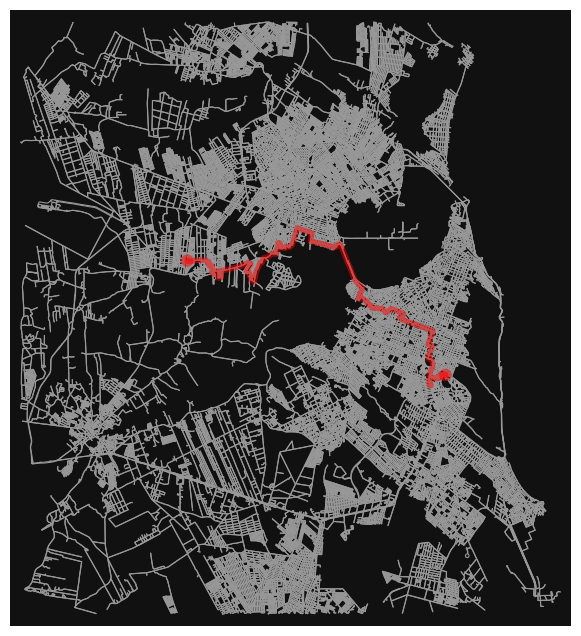

In [69]:
# plotando o mapa e rota de solução:

fig, ax = ox.plot_graph(G, show = False, close = False, node_size = 0, edge_linewidth = 0.8)
ox.plot_graph_route(G, path_nodes, ax = ax, route_linewidth = 4, orig_dest_size = 80, show = False, close = False)
plt.show()

#### **2.2 Análise:**
<font size=3>

Em uma **célula de markdown** descreva as principais características do algoritmo que você escolheu, respondendo:

- **Heurística:** Qual foi a função heurística `h(n)` que você utilizou para guiar a busca?

- **Função de Avaliação:** Como o seu algoritmo prioriza os nós na fronteira? Ele usa apenas a heurística $h(n)$, como a Busca Gananciosa, ou uma combinação de custo e heurística $f(n) = g(n) + h(n)$, como o A*?

- **Otimalidade:** A rota encontrada pelo seu algoritmo é **garantidamente** a de menor custo (menor distância total)? Explique como a sua escolha de heurística e função de avaliação afeta essa garantia.

  